# Phase 4b — three sign architectures across the (hx, hz) plane

Relative energy error of the three sign-aware arms on the doubled semion,
graded against exact references (`results/diagnostics/signfid_*.json`,
`results/ed/ed_hc*_ds_*.json`). rel-err = |E_tail − E0|/|E0| with E_tail the
median of the last 20 training energies. Identical recipe everywhere: minSR,
lr 0.01, 350 steps, seed 0, 8192 samples. Only completed runs (`.mpack`
present) are shown; missing cells are grey (cnnqC runs still in the queue —
re-execute after the final fetch).

| arm | architecture |
|---|---|
| **cnnqB** | real trunk + QEC head (sign-framed Hamiltonian) |
| **cnnqC** | complex trunk + QEC head |
| **cnnqR** | real trunk + QEC head + tie-gated residual phase MLP |

Full numeric table incl. the ceiling columns (1−F_s, 1−F_plus): `python scripts/phase4b_summary.py`.

In [1]:
import os, sys, glob, re, pathlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# house plot style (shared with the toric-code-nqs repo)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
FIGDIR = "figures"

ROOT = pathlib.Path.cwd()
if ROOT.name == 'analysis':
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from scripts.phase4b_summary import load_refs, tail_stats

ARMS = ['cnnqB', 'cnnqC', 'cnnqR']
ARM_LABEL = {'cnnqB': 'B: real trunk + head',
             'cnnqC': 'C: complex trunk + head',
             'cnnqR': 'R: real trunk + head + residual'}
ARM_COLOR = {'cnnqB': '#0072B2', 'cnnqC': '#E69F00', 'cnnqR': '#009E73'}  # Okabe-Ito

refs = load_refs()
pat = re.compile(r'G-equiv_1_hc(\d+x\d+)_ds_(?:h0|hx([\d.]+)_hz([\d.]+))_(\w+)\.json$')
rel = {}
for f in glob.glob('results/nqs/G-equiv_1_hc*_ds_*.json'):
    if not os.path.exists(f.replace('.json', '.mpack')):
        continue                       # completed runs only
    m = pat.search(os.path.basename(f))
    if not m or m.group(4) not in ARMS:
        continue
    key = (m.group(1), round(float(m.group(2) or 0), 6), round(float(m.group(3) or 0), 6))
    e0 = refs.get(key, {}).get('E0')
    if e0:
        E, V, _, _, _ = tail_stats(f)
        rel[key + (m.group(4),)] = abs(E - e0) / abs(e0)
print(f'{len(rel)} completed graded runs loaded')

89 completed graded runs loaded


Text(0.5, 1.06, 'DS 2x2 (19 qubits): rel. energy error field (cubic interpolation of the annotated measured points)')

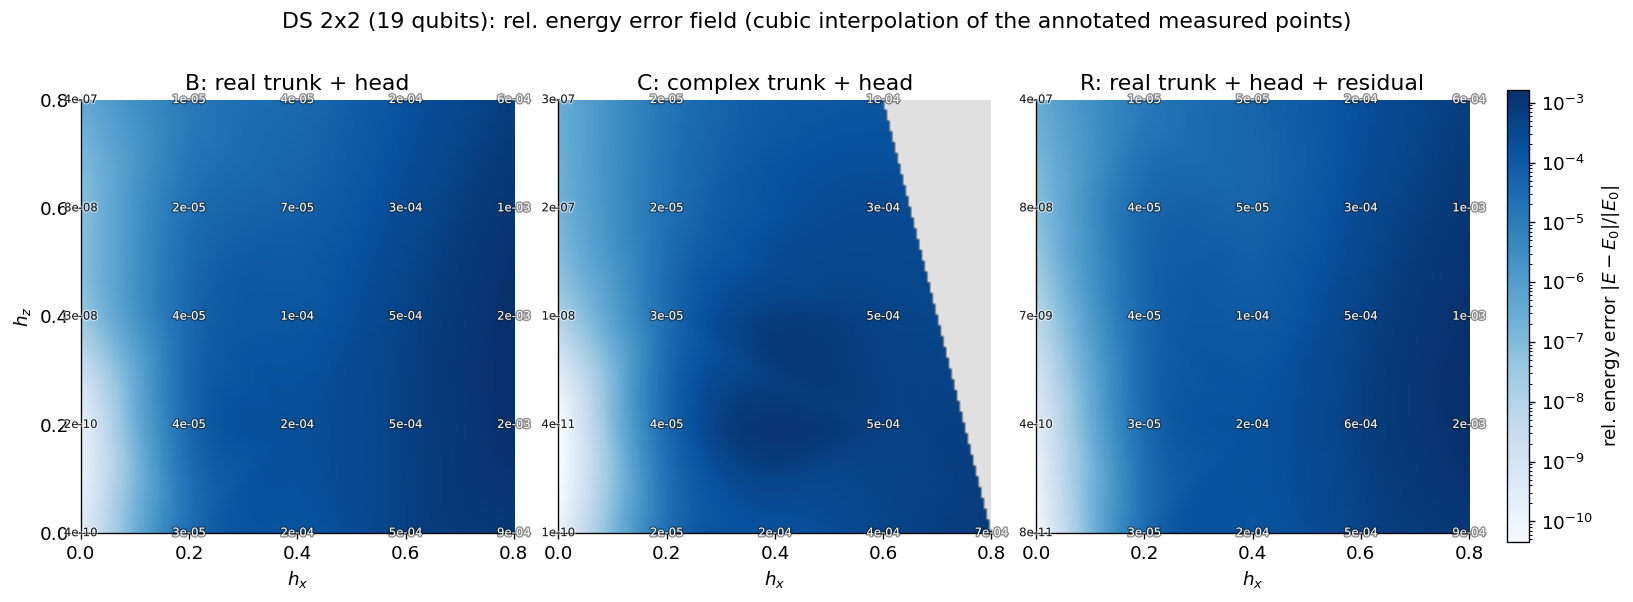

In [2]:
# 2x2: continuous error field per architecture (cubic interpolation in log10 space)
from scipy.interpolate import griddata
import matplotlib.patheffects as pe

VALS = [0.0, 0.2, 0.4, 0.6, 0.8]
pts, logv = {}, {}
for arm in ARMS:
    p, v = [], []
    for hz in VALS:
        for hx in VALS:
            r = rel.get(('2x2', hx, hz, arm))
            if r is not None:
                p.append((hx, hz)); v.append(np.log10(r))
    pts[arm], logv[arm] = np.array(p), np.array(v)

allv = np.concatenate(list(logv.values()))
vmin, vmax = allv.min(), allv.max()
norm = LogNorm(vmin=10**vmin, vmax=10**vmax)
g = np.linspace(0, 0.8, 161)
GX, GY = np.meshgrid(g, g)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharey=True, constrained_layout=True)
for ax, arm in zip(axes, ARMS):
    ax.grid(False)
    F = np.clip(griddata(pts[arm], logv[arm], (GX, GY), method='cubic'), vmin, vmax)
    im = ax.imshow(10**np.ma.masked_invalid(F), origin='lower', extent=(0, 0.8, 0, 0.8),
                   cmap='Blues', norm=norm, interpolation='bilinear')
    ax.set_facecolor('0.88')
    # measured points stay annotated -- everything else is interpolation
    for (hx, hz), lv in zip(pts[arm], logv[arm]):
        dark = norm(10**lv) > 0.6
        ax.text(hx, hz, f'{10**lv:.0e}', ha='center', va='center', fontsize=7,
                color='white' if dark else '#1a1a1a',
                path_effects=[pe.withStroke(linewidth=1.6, alpha=0.5,
                              foreground='#1a1a1a' if dark else 'white')])
    ax.set_xticks(VALS); ax.set_yticks(VALS)
    ax.set(xlabel='$h_x$', title=ARM_LABEL[arm])
axes[0].set(ylabel='$h_z$')
cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.015)
cb.set_label(r'rel. energy error $|E - E_0|/|E_0|$')
fig.suptitle('DS 2x2 (19 qubits): rel. energy error field '
             '(cubic interpolation of the annotated measured points)', y=1.06)
# fig.savefig(f"{FIGDIR}/phase4b_2x2_relerr.png", dpi=300, bbox_inches="tight")

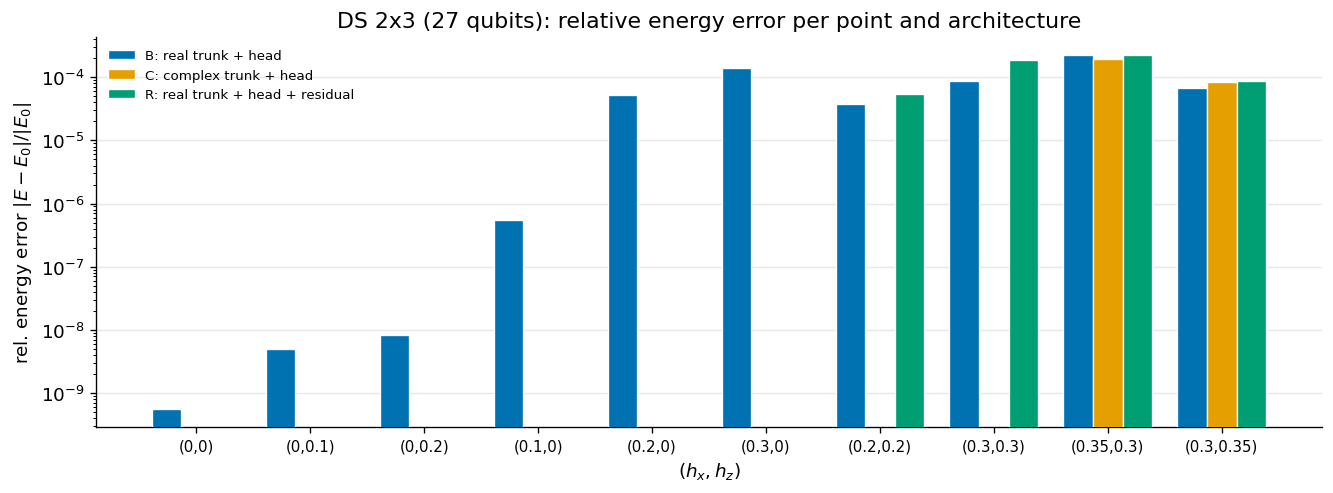

In [3]:
# 2x3 (27 qubits): all graded points, grouped bars per architecture
PTS = [(0.0, 0.0), (0.0, 0.1), (0.0, 0.2), (0.1, 0.0), (0.2, 0.0), (0.3, 0.0),
       (0.2, 0.2), (0.3, 0.3), (0.35, 0.3), (0.3, 0.35)]
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
w, x = 0.26, np.arange(len(PTS))
for k, arm in enumerate(ARMS):
    vals = [rel.get(('2x3', hx, hz, arm), np.nan) for hx, hz in PTS]
    ax.bar(x + (k - 1) * w, vals, w, color=ARM_COLOR[arm],
           label=ARM_LABEL[arm], edgecolor='white', linewidth=0.8, zorder=3)
ax.set_yscale('log')
ax.set_xticks(x, [f'({hx:g},{hz:g})' for hx, hz in PTS], fontsize=9)
ax.set(xlabel='$(h_x, h_z)$', ylabel=r'rel. energy error $|E - E_0|/|E_0|$',
       title='DS 2x3 (27 qubits): relative energy error per point and architecture')
ax.grid(axis='x')
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8, loc='upper left')
# fig.savefig(f"{FIGDIR}/phase4b_2x3_relerr.png", dpi=300, bbox_inches="tight")

## Achieved error vs the deterministic-head ceiling

Each marker is one (point, architecture): x = the head's measured ceiling
1−F_s at that point (from the exact sign-fidelity diagnostics), y = the
achieved rel-err. The dashed guide is y = x: markers far above it are
optimization-limited (the sign head is not the bottleneck); markers near it
are head-limited. Points with ceiling exactly 0 (the hx = 0 column) are
clipped to the left edge (dotted line).

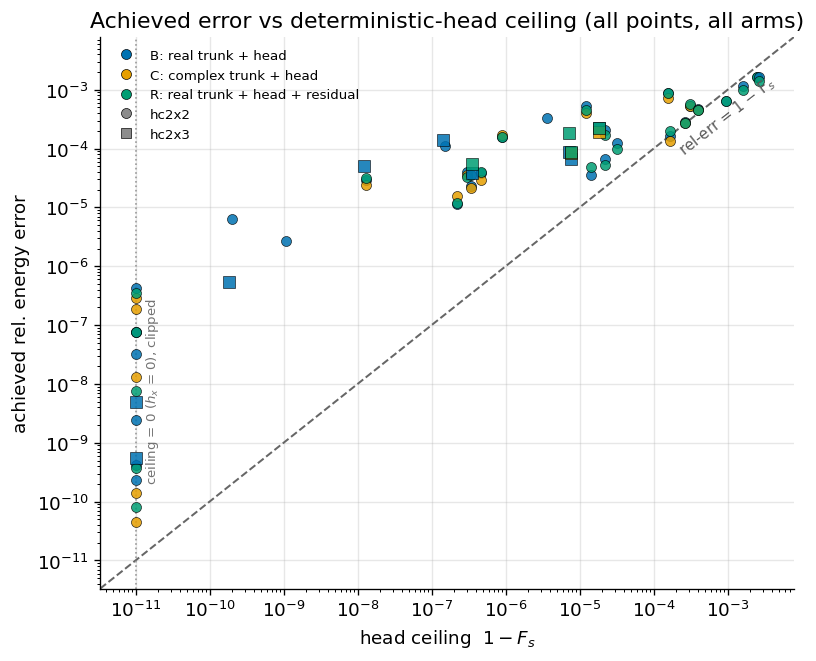

In [4]:
# achieved rel-err vs head ceiling (1 - F_s), log-log, y = x guide
from matplotlib.lines import Line2D

CLIP = 1e-11
MARK = {'2x2': 'o', '2x3': 's'}
xs, ys = [], []
fig, ax = plt.subplots(figsize=(6.6, 5.4), constrained_layout=True)
for (size, hx, hz, arm), y in sorted(rel.items()):
    fs = refs.get((size, hx, hz), {}).get('F_s')
    if fs is None:
        continue
    x = max(1.0 - fs, CLIP)
    xs.append(x); ys.append(y)
    ax.plot(x, y, MARK[size], color=ARM_COLOR[arm], ms=7 if size == '2x3' else 6,
            mec='k', mew=0.4, alpha=0.85, zorder=3)
lo = CLIP / 3
hi = 3 * max(max(xs), max(ys))
ax.plot([lo, hi], [lo, hi], '--', color='0.4', lw=1.2, zorder=2)
ax.text(2e-4, 8e-5, 'rel-err = 1 $-$ F$_s$', color='0.35', fontsize=9, rotation=38)
ax.axvline(CLIP, color='0.6', ls=':', lw=1)
ax.text(CLIP * 1.3, 2e-10, 'ceiling = 0 ($h_x$ = 0), clipped', color='0.45',
        fontsize=8, rotation=90, va='bottom')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set(xlabel=r'head ceiling  $1 - F_s$', ylabel=r'achieved rel. energy error',
       title='Achieved error vs deterministic-head ceiling (all points, all arms)')
handles = [Line2D([], [], marker='o', ls='', color=ARM_COLOR[a], mec='k', mew=0.4,
                  ms=6, label=ARM_LABEL[a]) for a in ARMS]
handles += [Line2D([], [], marker=m, ls='', color='0.55', mec='k', mew=0.4, ms=6,
                   label=f'hc{s}') for s, m in MARK.items()]
ax.legend(handles=handles, frameon=False, fontsize=8, loc='upper left')
# fig.savefig(f"{FIGDIR}/phase4b_ceiling_scatter.png", dpi=300, bbox_inches="tight")